# Entrenchment analysis of V-family DASM selection factors

This notebook identifies amino acid positions that are **entrenched** — resistant to reciprocal substitution — by comparing DASM selection factors across V gene families (IGHV1, IGHV3, IGHV4).

## Approach

At sites where V genes carry different germline amino acids (e.g., W and G at some site), we compare DASM-predicted selection factors for the reciprocal substitutions W→G and G→W. A site is classified as entrenched for an amino acid pair when both reciprocal median log selection factors fall below −1 (i.e., both substitutions occur at less than 37% of the neutral rate).

Selection factors are computed on a held-out test dataset (Rodriguez), restricted to:
- Most recent common ancestor (MRCA) sequences from each clonal family
- Germline-encoded sites only
- Single-nucleotide substitutions only
- ≥10 observations per site/amino acid/V family combination

We perform two types of comparisons:
- **Within-family**: comparing V genes within the same family (e.g., different IGHV1 genes). Entrenched sites cluster at CDR borders and germline-diverse positions.
- **Between-family**: comparing V genes across families (e.g., IGHV1 vs IGHV3). This retains most within-family sites and additionally identifies framework positions.

## Outputs

**Paper figures:**
- Reciprocal selection factor scatter plots (Figs 2A, 5A, S6, S12)
- Entrenchment mapped along the V gene sequence with germline diversity (Figs 2B, 5B, S6, S12)

**Intermediate data used by downstream notebooks and scripts:**
- `_output/entrenchment_analysis/chothia/comparison_*.csv` — full comparison tables
- `_output/entrenchment_analysis/chothia/entrenched_aa_sites_*.csv` — called entrenched sites


In [1]:
from tqdm.auto import tqdm
tqdm.pandas()

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from dnsmex.local import localify
from utils import load_and_process_dasm_data, GERMLINE_PATH_DICTIONARY, sort_antibody_sites, add_cdr_shading
from netam.sequences import AA_STR_SORTED
from dnsmex.local import localify

figures_dir = localify("FIGURES_DIR")

## Prep data - Rodriguez dataset

Adding one_mutation_away column (vectorized)...


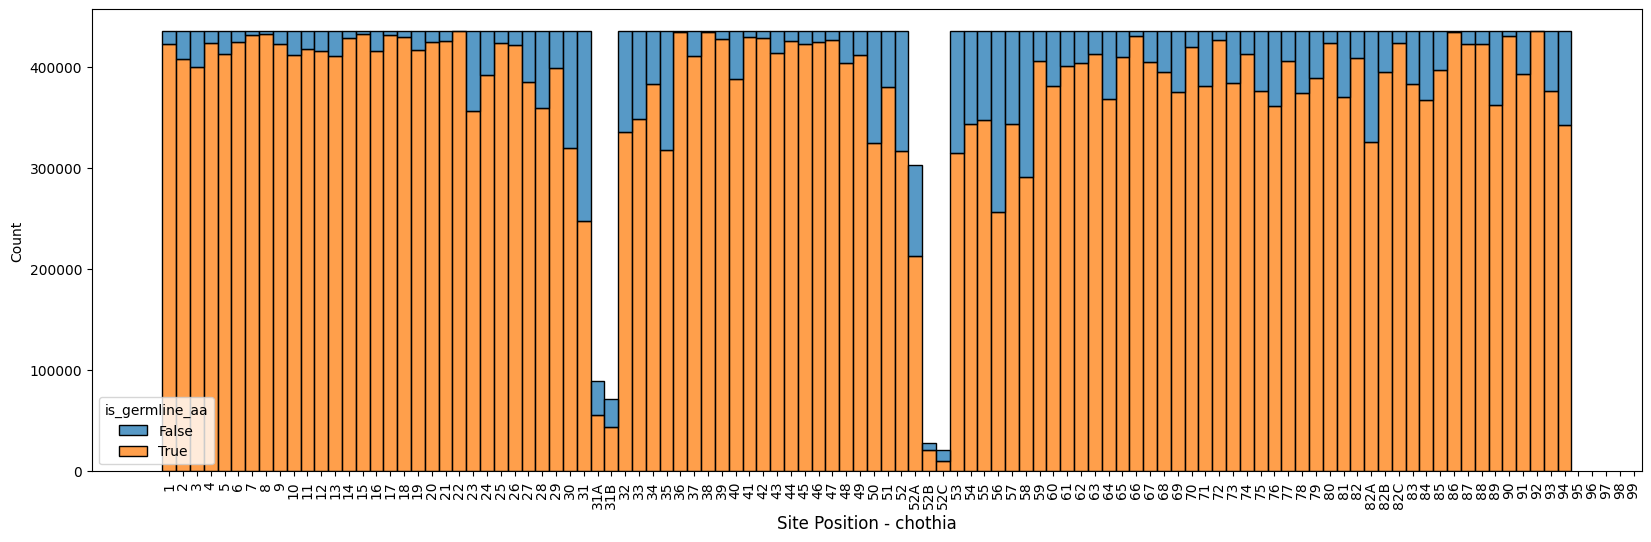

In [2]:
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"
dataset_name = "v1rodriguez"
numbering_scheme = 'chothia'


germline_codons_df = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})


site_sub_probs_df, pcp_df, aa_site_subs_selection_df_germline = load_and_process_dasm_data(
    model_name=model_name,
    dataset_name=dataset_name,
    numbering_scheme=numbering_scheme,
    figures_dir="figures"
)


fig, ax = plt.subplots(figsize=(20,6))
sns.histplot(aa_site_subs_selection_df_germline, x='site', hue='is_germline_aa', multiple='stack', ax=ax)
ax.set_xlabel(f'Site Position - {numbering_scheme}', fontsize=12)
ax.tick_params(axis='x', rotation=90)


In [3]:
# Get all unique amino acids to create consistent color palette
PALETTE_AA = dict(zip(AA_STR_SORTED, sns.color_palette('tab20', len(AA_STR_SORTED))))


# output dir for results
output_dir = f'_output/entrenchment_analysis/{numbering_scheme}/'
os.makedirs(output_dir, exist_ok=True)


### As an example, let's compare single V genes first. We can then extend this to comparing V families.

In [4]:
def compare_group_2_sites_between_vgenes(aa_site_subs_selection_df_germline, germline_codons_df, 
                                         v_gene1, v_gene2, numbering_scheme='imgt', 
                                         one_mutation_away=False, limit_pcp_depth=True):
    '''
    Compare two v genes at sites and aas that are not common in both v genes.
    
    Parameters:
    -----------
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    '''
    before_grouping = aa_site_subs_selection_df_germline.copy()
    if limit_pcp_depth:
        # Limit to only pcps that are 2 levels away from the naive, which are likely the most reliable
        before_grouping = before_grouping[before_grouping.depth == 2]

    if one_mutation_away:
        # Filter to only include mutations that are one mutation away        
        before_grouping = before_grouping[before_grouping['one_mutation_away'] == True]

    before_grouping = before_grouping[before_grouping.is_germline_codon == True]
    
    median_log_selection_factors_germline = before_grouping.groupby(['v_gene', 'site', 'parent_aa', 'selection_factor_target_aa', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    
    # which sites and amino acids are we comparing - all group 2 sites and their possbile amino acids
    temp_df = pd.merge(germline_codons_df[germline_codons_df.v_gene == v_gene1], germline_codons_df[germline_codons_df.v_gene == v_gene2], on=['site', 'amino_acid'], how='outer', suffixes=('_1', '_2'))

    temp_df['is_common_germline_aa'] = (temp_df['codon_1'].isna() == False) & (temp_df['codon_2'].isna() == False)
    temp_df = temp_df[temp_df['is_common_germline_aa'] == False]
    v_gene_1_sites = temp_df[['site', 'amino_acid', 'v_gene_1']].dropna().drop_duplicates()
    v_gene_2_sites = temp_df[['site', 'amino_acid', 'v_gene_2']].dropna().drop_duplicates()
    
    # merge with median log selection factors
    median_log_selection_factors_germline.dropna(subset=['log_selection_factor'], inplace=True)
    median_log_selection_factors_1 = pd.merge(v_gene_1_sites.rename(columns={'v_gene_1':'v_gene', 'amino_acid':'parent_aa'}), median_log_selection_factors_germline, how='left', on=['site', 'parent_aa', 'v_gene', ])
    median_log_selection_factors_2 = pd.merge(v_gene_2_sites.rename(columns={'v_gene_2':'v_gene', 'amino_acid':'parent_aa'}), median_log_selection_factors_germline, how='left', on=['site', 'parent_aa', 'v_gene', ])

    # change the column names to describe selection direction
    median_log_selection_factors_1.rename(columns={'parent_aa':'parent_aa_1_and_target_aa_2', 'selection_factor_target_aa':'parent_aa_2_and_target_aa_1'}, inplace=True)
    median_log_selection_factors_2.rename(columns={'parent_aa':'parent_aa_2_and_target_aa_1', 'selection_factor_target_aa':'parent_aa_1_and_target_aa_2'}, inplace=True)

    compare_df = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1', 'is_cdr'], how='inner', suffixes=('_1', '_2'))
    plot_temp_df = pd.melt(compare_df, id_vars=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1', 'is_cdr'], value_vars=['log_selection_factor_1', 'log_selection_factor_2'], var_name='v_gene', value_name='log_selection_factor')

    # Sort sites properly
    sorted_sites = sort_antibody_sites(plot_temp_df['site'].unique())
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    # === First plot: Bar plot ===
    fig, ax = plt.subplots(1, 1, figsize=(20, 5))
    
    # Add CDR shading
    add_cdr_shading(ax, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Plot each hue group separately with position mapping
    for v_gene in plot_temp_df['v_gene'].unique():
        subset = plot_temp_df[plot_temp_df['v_gene'] == v_gene]
        x_positions = [site_to_position[site] for site in subset['site']]
        ax.bar(x_positions, subset['log_selection_factor'], 
               alpha=0.5, label=v_gene, width=0.8)

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Site')
    ax.set_ylabel('Log Selection Factor')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis ticks to show site labels
    ax.set_xticks(range(len(sorted_sites)))
    ax.set_xticklabels(sorted_sites, rotation=90)

    # === Second plot: Sum scatter plot ===
    compare_df['sum'] = compare_df['log_selection_factor_1'] + compare_df['log_selection_factor_2']
    compare_df['is_entrenched'] = (compare_df['log_selection_factor_1'] < -1) & (compare_df['log_selection_factor_2'] < -1)

    fig, ax = plt.subplots(1, 1, figsize=(20, 6))
    
    # Add CDR shading
    add_cdr_shading(ax, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Plot with color based on significance
    for is_sig in compare_df['is_entrenched'].unique():
        subset = compare_df[compare_df['is_entrenched'] == is_sig]
        subset_x = [site_to_position[site] for site in subset['site']]
        ax.scatter(subset_x, subset['sum'], 
                   alpha=0.7, label=f'entrenched: {is_sig}')
    
    ax.set_xlabel('Site')
    ax.set_ylabel('Sum of Median Log Selection Factors')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis ticks
    ax.set_xticks(range(len(sorted_sites)))
    ax.set_xticklabels(sorted_sites, rotation=90)


    return compare_df


,site,parent_aa_1_and_target_aa_2,v_gene_1,parent_aa_2_and_target_aa_1,is_cdr,log_selection_factor_1,v_gene_2,log_selection_factor_2,sum,is_entrenched
0,1,E,IGHV3-15*01,Q,False,0.692269,IGHV2-5*02,-2.687220,-1.994951,False
1,17,S,IGHV3-15*01,T,False,-1.668166,IGHV2-5*02,-1.286147,-2.954313,True
2,19,R,IGHV3-15*01,T,False,1.004200,IGHV2-5*02,-2.927957,-1.923757,False
3,21,S,IGHV3-15*01,T,False,-0.832751,IGHV2-5*02,-2.350979,-3.183730,False
4,23,A,IGHV3-15*01,T,False,0.599002,IGHV2-5*02,-0.075854,0.523148,False
5,28,T,IGHV3-15*01,S,True,0.556248,IGHV2-5*02,-1.603394,-1.047146,False
6,29,F,IGHV3-15*01,L,True,-0.681341,IGHV2-5*02,-0.799075,-1.480416,False
7,31,N,IGHV3-15*01,T,True,0.163164,IGHV2-5*02,-0.191943,-0.028780,False
8,32,A,IGHV3-15*01,V,True,0.083865,IGHV2-5*02,-0.044989,0.038876,False
9,34,M,IGHV3-15*01,V,False,-1.639028,IGHV2-5*02,-1.069951,-2.708978,True


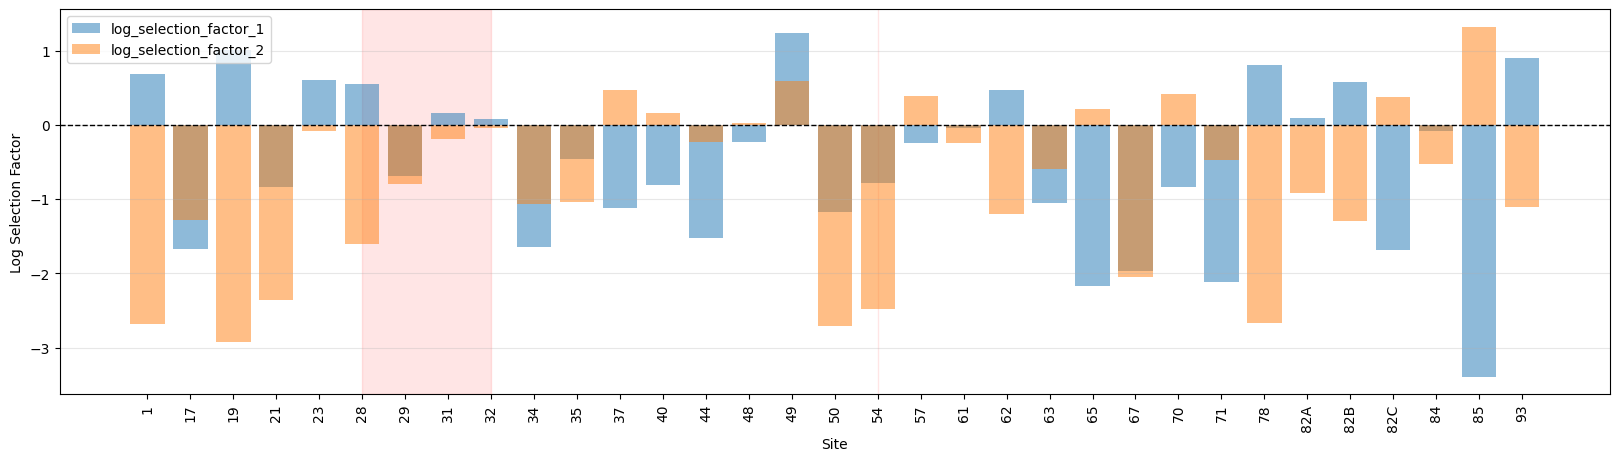

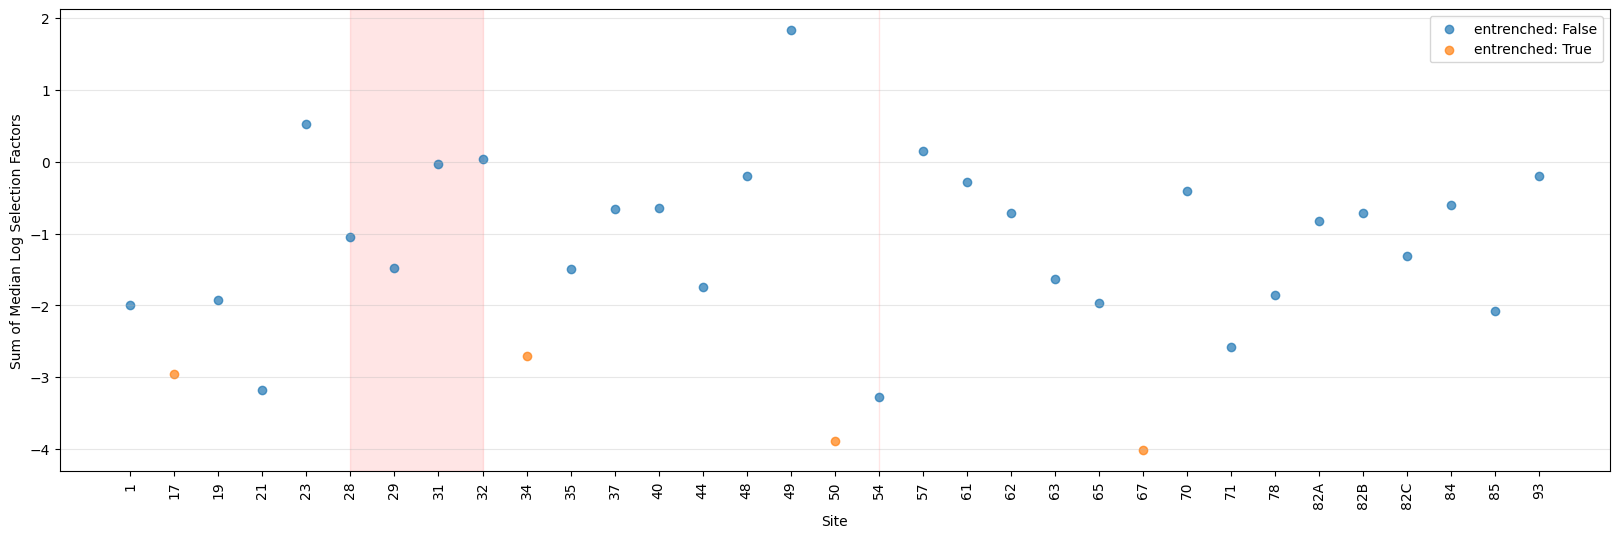

In [5]:
compare_group_2_sites_between_vgenes(aa_site_subs_selection_df_germline, germline_codons_df, 'IGHV3-15*01', 'IGHV2-5*02', one_mutation_away=True, limit_pcp_depth=True, numbering_scheme=numbering_scheme)


## Compare V families to find entrenchment - within v-family and between v family comparisons

In [6]:
### separate function for within the same v family and between two different v families

def compare_group_2_sites_between_vfamilies_with_distribution(aa_site_subs_selection_df_germline, germline_codons_df, 
                                                              v_family1, v_family2, numbering_scheme='imgt',
                                                              one_mutation_away=True, limit_pcp_depth=True, remove_rare_aas=True,
                                                              figsize=(20, 7), save_results=False, threshold=-1):
    '''
    Compare two v families at sites and aas that are not common in both v genes to find entrenchment.
    Enhanced version with germline amino acid distribution plot below the scatter plot.
    
    Parameters:
    -----------
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    '''
    # calculate and merge reciprocal selection factors for germline amino acids at each site
    before_grouping = aa_site_subs_selection_df_germline.copy()
    if limit_pcp_depth:
        before_grouping = before_grouping[before_grouping.depth == 2]

    if one_mutation_away:
        before_grouping = before_grouping[before_grouping['one_mutation_away'] == True]

    before_grouping = before_grouping[before_grouping.is_germline_codon == True]
    before_grouping.dropna(subset=['log_selection_factor'], inplace=True) # drop na in cases where Q>Q

    if remove_rare_aas:
        # filter to only include amino acids that are seen in more than 10 sequences in either family
        counts_of_aa_site_family = before_grouping[['v_family', 'site', 'parent_aa', 'pcp_index']].drop_duplicates().groupby(['v_family', 'site', 'parent_aa']).size().reset_index(name='count')
        counts_of_aa_site_family = counts_of_aa_site_family[counts_of_aa_site_family['count'] >= 10]
        before_grouping = pd.merge(before_grouping, counts_of_aa_site_family[['v_family', 'site', 'parent_aa']], on=['v_family', 'site', 'parent_aa'], how='inner')

    median_log_selection_factors_germline = before_grouping.groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).log_selection_factor.median().reset_index().copy()

    median_log_selection_factors_1 = median_log_selection_factors_germline[median_log_selection_factors_germline.v_family == v_family1].copy()
    median_log_selection_factors_2 = median_log_selection_factors_germline[median_log_selection_factors_germline.v_family == v_family2].copy()
    median_log_selection_factors_1.rename(columns={'parent_aa':'parent_aa_1_and_target_aa_2', 'selection_factor_target_aa':'parent_aa_2_and_target_aa_1'}, inplace=True)
    median_log_selection_factors_2.rename(columns={'parent_aa':'parent_aa_2_and_target_aa_1', 'selection_factor_target_aa':'parent_aa_1_and_target_aa_2'}, inplace=True)

    compare_df = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1'], how='inner', suffixes=('_1', '_2'))
    
    compare_df['sum'] = compare_df['log_selection_factor_1'] + compare_df['log_selection_factor_2']
    compare_df['is_entrenched'] = (compare_df['log_selection_factor_1'] < threshold) & (compare_df['log_selection_factor_2'] < threshold)


    if save_results:
        # Save the full comparison dataframe
        compare_df.to_csv(f'{output_dir}/comparison_{v_family1}_vs_{v_family2}.csv', index=False)
        
        # Save entrenched sites (where both < -1)
        if 'is_entrenched' in compare_df.columns:
            entrenched_df = compare_df[compare_df['is_entrenched'] == True].copy()
            
            # For v_family1 - get unique site/amino_acid/target_amino_acid combinations
            entrenched_aa_sites_vfam1 = entrenched_df[['v_family_1', 'site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1']]\
                .rename(columns={'v_family_1':'v_family', 'parent_aa_1_and_target_aa_2':'amino_acid', 'parent_aa_2_and_target_aa_1':'target_amino_acid'})\
                .drop_duplicates()\
                .sort_values(by='site')
            
            # For v_family2
            entrenched_aa_sites_vfam2 = entrenched_df[['v_family_2', 'site', 'parent_aa_2_and_target_aa_1', 'parent_aa_1_and_target_aa_2']]\
                .rename(columns={'v_family_2':'v_family', 'parent_aa_2_and_target_aa_1':'amino_acid', 'parent_aa_1_and_target_aa_2':'target_amino_acid'})\
                .drop_duplicates()\
                .sort_values(by='site')
            
            # Concatenate and save
            pd.concat([entrenched_aa_sites_vfam1, entrenched_aa_sites_vfam2]).sort_values(['v_family','site'])\
                .to_csv(f'{output_dir}/entrenched_aa_sites_{v_family1}_vs_{v_family2}.csv', index=False)


    # Get data for amino acid distribution
    family1_data = germline_codons_df[germline_codons_df.v_family == v_family1].copy()
    family2_data = germline_codons_df[germline_codons_df.v_family == v_family2].copy()
    
    # Get all sites and sort them properly
    all_sites_with_data = sorted(set(family1_data['site'].unique()) | set(family2_data['site'].unique()))
    sorted_sites = sort_antibody_sites(all_sites_with_data)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    # Check for data
    if len(sorted_sites) == 0:
        print("Warning: No data found for one or both V families")
        return compare_df, None, None
    
    # ===== CREATE COMBINED PLOT =====
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # ===== TOP PLOT: SCATTER PLOT =====
    # Add CDR shading first
    add_cdr_shading(ax1, sorted_sites, numbering_scheme=numbering_scheme)
    
    
    for is_sig in compare_df['is_entrenched'].unique():
        subset = compare_df[compare_df['is_entrenched'] == is_sig]
        subset_x = [site_to_position[site] for site in subset['site']]
        color = '#262626' if is_sig else '#D4D2D2'
        label = 'entrenched' if is_sig else 'not entrenched'
        ax1.scatter(subset_x, subset['sum'], 
                    alpha=0.85, label=label, color=color, edgecolor='black', linewidth=0.5)
    
    ax1.set_ylabel('Sum of median\nlog selection factors', fontsize=17)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.set_title(f'Entrenchment between {v_family1} and {v_family2}', fontsize=20)
    ax1.grid(True, axis='y', alpha=0.4, linewidth=0.8)
    for i in range(0, len(sorted_sites), 2):
        ax1.axvline(i, color='lightgray', alpha=0.4, linewidth=0.8)
    ax1.legend(bbox_to_anchor=(1.02, 0.8), loc='upper left', fontsize=17)
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION =====
    # Add CDR shading first
    add_cdr_shading(ax2, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Calculate percentages for family1 at specific sites
    family1_site_counts = {}
    for aa in AA_STR_SORTED:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family1_site_counts[aa] = site_counts
    
    # Calculate percentages for family2 at specific sites  
    family2_site_counts = {}
    for aa in AA_STR_SORTED:
        aa_data = family2_data[family2_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family2_site_counts[aa] = site_counts
    
    # Plot family1 above x-axis (positive values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom1 = 0
        #site_total = sum([family1_site_counts[aa].get(site, 0) for aa in AA_STR_SORTED])
        site_total = family1_data['v_gene'].nunique()

        
        for aa in AA_STR_SORTED:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site_pos, percentage, bottom=bottom1, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Plot family2 below x-axis (negative values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom2 = 0
        #site_total = sum([family2_site_counts[aa].get(site, 0) for aa in AA_STR_SORTED])
        site_total = family2_data['v_gene'].nunique()

        
        for aa in AA_STR_SORTED:
            count = family2_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = -(count / site_total) * 100  # Negative for below x-axis
                ax2.bar(site_pos, percentage, bottom=bottom2, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom2 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'Germline AA\ndistribution\n\n', fontsize=17)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1.5, zorder=0)
    # Add family labels to top and bottom halves
    ax2.text(-0.01, 0.75, v_family1, transform=ax2.transAxes, fontsize=16, ha='right', va='center', rotation=90)
    ax2.text(-0.01, 0.25, v_family2, transform=ax2.transAxes, fontsize=16, ha='right', va='center', rotation=90)

    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in AA_STR_SORTED:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=PALETTE_AA[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, 
              bbox_to_anchor=(1.02, 1.2), loc='upper left', 
              ncol=2, fontsize=15, title='Amino Acids', title_fontsize=17)
    
    # Set x-axis for both plots
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax2.set_xlim(-0.5, len(sorted_sites) - 0.5)
    
    # Set x-axis ticks - every other for grid, all for labels
    ax1.set_xticks(range(0, len(sorted_sites), 2))  # Grid at every other position
    ax2.set_xticks(range(len(sorted_sites)))
    
    # Only show x-tick labels on bottom plot
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site position', fontsize=17)
    ax2.set_xticklabels(sorted_sites, rotation=90, fontsize=12)
    ax2.set_yticks([])
    
    plt.tight_layout()

    if save_results:
        fig.savefig(f'{output_dir}/{v_family1}_vs_{v_family2}_group2_sites_comparison.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()

    plot_reciprocal_selection_factors_between_vfamilies(compare_df, v_family1, v_family2, save_results=save_results)

    return compare_df

def compare_group_2_sites_within_vfamily_with_distribution(aa_site_subs_selection_df_germline, germline_codons_df, 
                                                              v_family1, numbering_scheme='imgt',
                                                              one_mutation_away=True, limit_pcp_depth=True, remove_rare_aas=True,
                                                              figsize=(20, 7), save_results=False, threshold=-1):
    '''
    Compare within v families at sites that have more than one possible aa to find entrenchment.
    Enhanced version with germline amino acid distribution plot below the scatter plot.
    
    Parameters:
    -----------
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    '''
    # calculate and merge reciprocal selection factors for germline amino acids at each site
    before_grouping = aa_site_subs_selection_df_germline.copy()
    if limit_pcp_depth:
        before_grouping = before_grouping[before_grouping.depth == 2]

    if one_mutation_away:
        before_grouping = before_grouping[before_grouping['one_mutation_away'] == True]

    before_grouping = before_grouping[before_grouping.is_germline_codon == True]
    before_grouping.dropna(subset=['log_selection_factor'], inplace=True) # drop na in cases where Q>Q

    if remove_rare_aas:
        # filter to only include amino acids that are seen in more than 10 sequences in either family
        counts_of_aa_site_family = before_grouping[['v_family', 'site', 'parent_aa', 'pcp_index']].drop_duplicates().groupby(['v_family', 'site', 'parent_aa']).size().reset_index(name='count')
        counts_of_aa_site_family = counts_of_aa_site_family[counts_of_aa_site_family['count'] >= 10]
        before_grouping = pd.merge(before_grouping, counts_of_aa_site_family[['v_family', 'site', 'parent_aa']], on=['v_family', 'site', 'parent_aa'], how='inner')

    median_log_selection_factors_germline = before_grouping.groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).log_selection_factor.median().reset_index().copy()

    median_log_selection_factors_1 = median_log_selection_factors_germline[median_log_selection_factors_germline.v_family == v_family1].copy()
    median_log_selection_factors_2 = median_log_selection_factors_1.copy()
    median_log_selection_factors_1.rename(columns={'parent_aa':'parent_aa_1_and_target_aa_2', 'selection_factor_target_aa':'parent_aa_2_and_target_aa_1'}, inplace=True)
    median_log_selection_factors_2.rename(columns={'parent_aa':'parent_aa_2_and_target_aa_1', 'selection_factor_target_aa':'parent_aa_1_and_target_aa_2'}, inplace=True)

    compare_df = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1'], how='inner', suffixes=('_1', '_2'))
    
    compare_df['sum'] = compare_df['log_selection_factor_1'] + compare_df['log_selection_factor_2']
    compare_df['is_entrenched'] = (compare_df['log_selection_factor_1'] < threshold) & (compare_df['log_selection_factor_2'] < threshold)

    if save_results:
        # Save the full comparison dataframe
        compare_df.to_csv(f'{output_dir}/comparison_within_{v_family1}.csv', index=False)
        
        # Save entrenched sites (where both < -1)
        if 'is_entrenched' in compare_df.columns:
            entrenched_df = compare_df[compare_df['is_entrenched'] == True].copy()
            
            # Get sites and amino acids that show entrenchment within a v family
            entrenched_aa_sites = entrenched_df[['v_family_1', 'site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1']]\
                .rename(columns={'v_family_1':'v_family', 'parent_aa_1_and_target_aa_2':'amino_acid', 'parent_aa_2_and_target_aa_1':'target_amino_acid'})\
                .drop_duplicates()\
                .sort_values(by='site')
            
            # Save
            entrenched_aa_sites.to_csv(f'{output_dir}/entrenched_aa_sites_within_{v_family1}.csv', index=False)



    # Get data for amino acid distribution
    family1_data = germline_codons_df[germline_codons_df.v_family == v_family1].copy()
    
    # Get all sites and sort them properly
    all_sites_with_data = sorted(set(family1_data['site'].unique()))
    sorted_sites = sort_antibody_sites(all_sites_with_data)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    # Check for data
    if len(sorted_sites) == 0:
        print("Warning: No data found for one or both V families")
        return compare_df, None, None
    
    # ===== CREATE COMBINED PLOT =====
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # ===== TOP PLOT: SCATTER PLOT =====
    # Add CDR shading first
    add_cdr_shading(ax1, sorted_sites, numbering_scheme=numbering_scheme)
    
    for is_sig in compare_df['is_entrenched'].unique():
        subset = compare_df[compare_df['is_entrenched'] == is_sig]
        # because compares within v family, there is duplication of the aa combinations (A->D and D->A) - we can drop the duplicates for plotting
        subset = subset[subset.parent_aa_1_and_target_aa_2 < subset.parent_aa_2_and_target_aa_1]
        
        subset_x = [site_to_position[site] for site in subset['site']]
        color = '#262626' if is_sig else '#D4D2D2'
        label = 'entrenched' if is_sig else 'not entrenched'
        ax1.scatter(subset_x, subset['sum'], 
                    alpha=0.85, label=label, color=color, edgecolor='black', linewidth=0.5)
    
    ax1.set_ylabel('Sum of median\nlog selection factors', fontsize=17)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.set_title(f'Entrenchment within {v_family1}', fontsize=20)
    ax1.grid(True, axis='y', alpha=0.4, linewidth=0.8)
    for i in range(0, len(sorted_sites), 2):
        ax1.axvline(i, color='lightgray', alpha=0.4, linewidth=0.8)
    ax1.legend(bbox_to_anchor=(1.02, 0.8), loc='upper left', fontsize=17)
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION =====
    # Add CDR shading first
    add_cdr_shading(ax2, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Calculate percentages for family1 at specific sites
    family1_site_counts = {}
    for aa in AA_STR_SORTED:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family1_site_counts[aa] = site_counts
    
    # Plot family1 above x-axis (positive values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom1 = 0
        #site_total = sum([family1_site_counts[aa].get(site, 0) for aa in AA_STR_SORTED])
        site_total = family1_data['v_gene'].nunique()
        
        for aa in AA_STR_SORTED:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site_pos, percentage, bottom=bottom1, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'Germline AA\ndistribution\n', fontsize=17)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1, zorder=0)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in AA_STR_SORTED:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=PALETTE_AA[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, bbox_to_anchor=(1.02, 1.2), loc='upper left', 
              title='Amino Acids', fontsize=15, title_fontsize=17, ncol=2)
    
    # Set x-axis for both plots
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax2.set_xlim(-0.5, len(sorted_sites) - 0.5)
    
    # Set x-axis ticks - every other for grid, all for labels
    ax1.set_xticks(range(0, len(sorted_sites), 2))  # Grid at every other position
    ax2.set_xticks(range(len(sorted_sites)))
    
    # Only show x-tick labels on bottom plot
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site position', fontsize=17)
    ax2.set_xticklabels(sorted_sites, rotation=90, fontsize=12)
    ax2.set_yticks([])
    
    plt.tight_layout()

    if save_results:
        fig.savefig(f'{output_dir}/within_{v_family1}_group2_sites_comparison.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()

    plot_reciprocal_selection_factors_within_vfamily(compare_df, v_family1, save_results=save_results)

    return compare_df

def plot_reciprocal_selection_factors_within_vfamily(compare_df, v_family, save_results=False):
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    
    for is_sig in compare_df['is_entrenched'].unique():
        subset = compare_df[compare_df['is_entrenched'] == is_sig]
        subset = subset[subset.parent_aa_1_and_target_aa_2 < subset.parent_aa_2_and_target_aa_1] # because compares within v family, there is duplication of the aa combinations (A->D and D->A) - we can drop the duplicates for plotting
        color = '#262626' if is_sig else '#D4D2D2'
        label = 'entrenched' if is_sig else 'not entrenched'
        ax.scatter(subset['log_selection_factor_1'], 
                   subset['log_selection_factor_2'],
                   alpha=0.85, label=label, color=color, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel(r'Selection $A \to B$')
    ax.set_ylabel(r'Selection $B \to A$')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(v_family)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xlim(-4.2, 2)
    ax.set_ylim(-4.2, 2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    if save_results:
        fig.savefig(f'{output_dir}/within_{v_family}_group2_sites_reciprocal_selection.pdf', dpi=300, bbox_inches='tight')
    plt.show()


def plot_reciprocal_selection_factors_between_vfamilies(compare_df, v_family1, v_family2, save_results=False):
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    
    for is_sig in compare_df['is_entrenched'].unique():
        subset = compare_df[compare_df['is_entrenched'] == is_sig]
        color = '#262626' if is_sig else '#D4D2D2'
        label = 'entrenched' if is_sig else 'not entrenched'
        ax.scatter(subset['log_selection_factor_1'], 
                   subset['log_selection_factor_2'],
                   alpha=0.85, label=label, color=color, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel(f'{v_family1} ' + r'selection $A \to B$')
    ax.set_ylabel(f'{v_family2} ' + r'selection $B \to A$')

    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{v_family1} vs {v_family2}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xlim(-4.2, 2)
    ax.set_ylim(-4.2, 2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    if save_results:
        fig.savefig(f'{output_dir}/{v_family1}_vs_{v_family2}_group2_sites_reciprocal_selection.pdf', dpi=300, bbox_inches='tight')
    plt.show()



/tmp/ipykernel_120669/2572439647.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


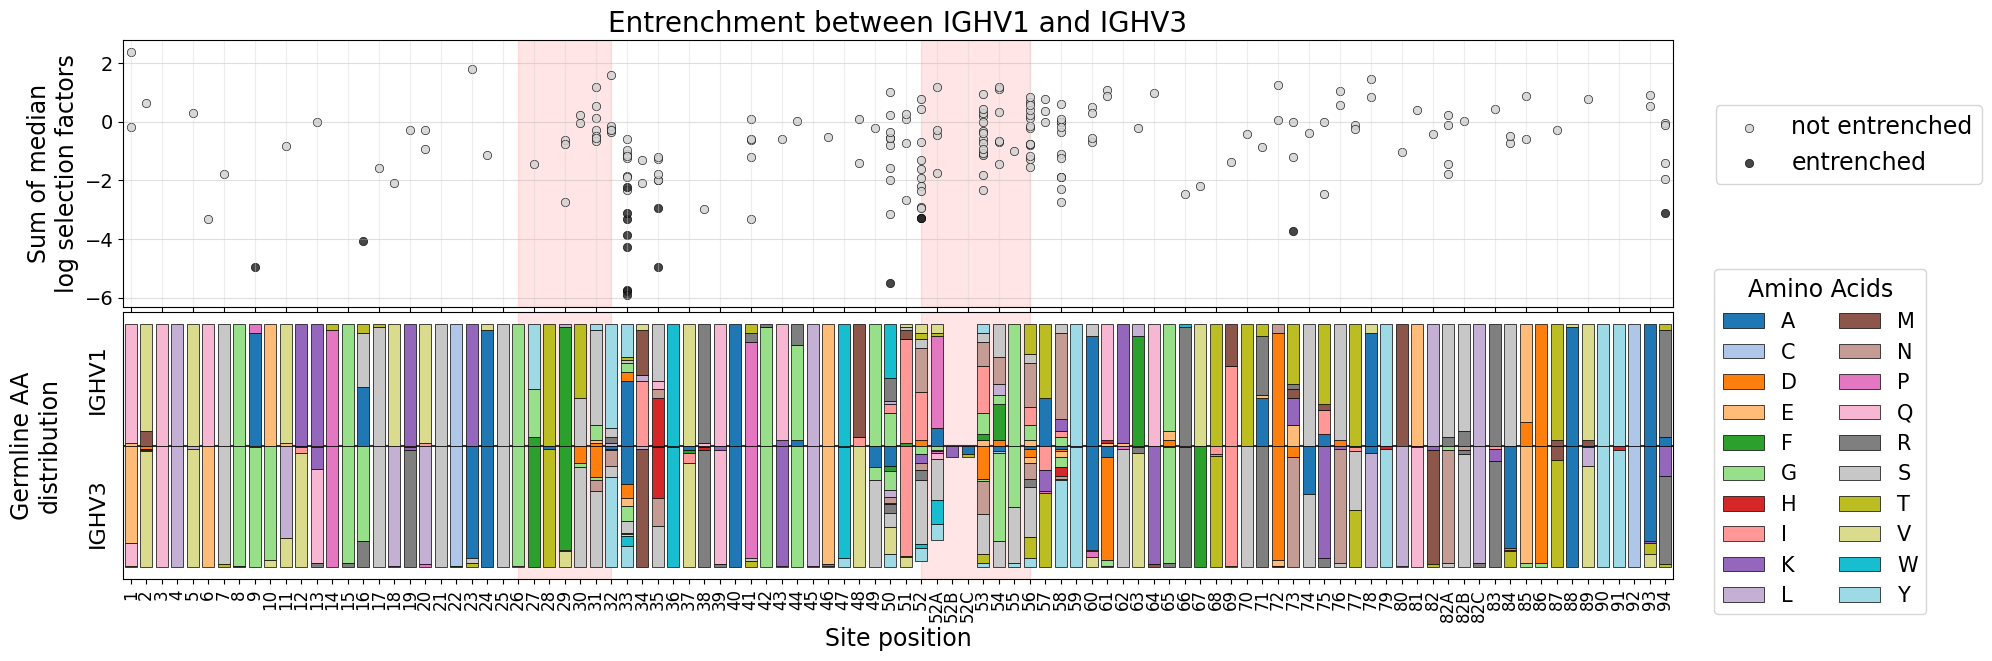

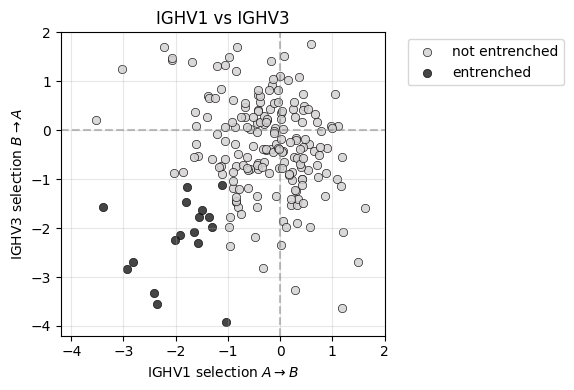

/tmp/ipykernel_120669/2572439647.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


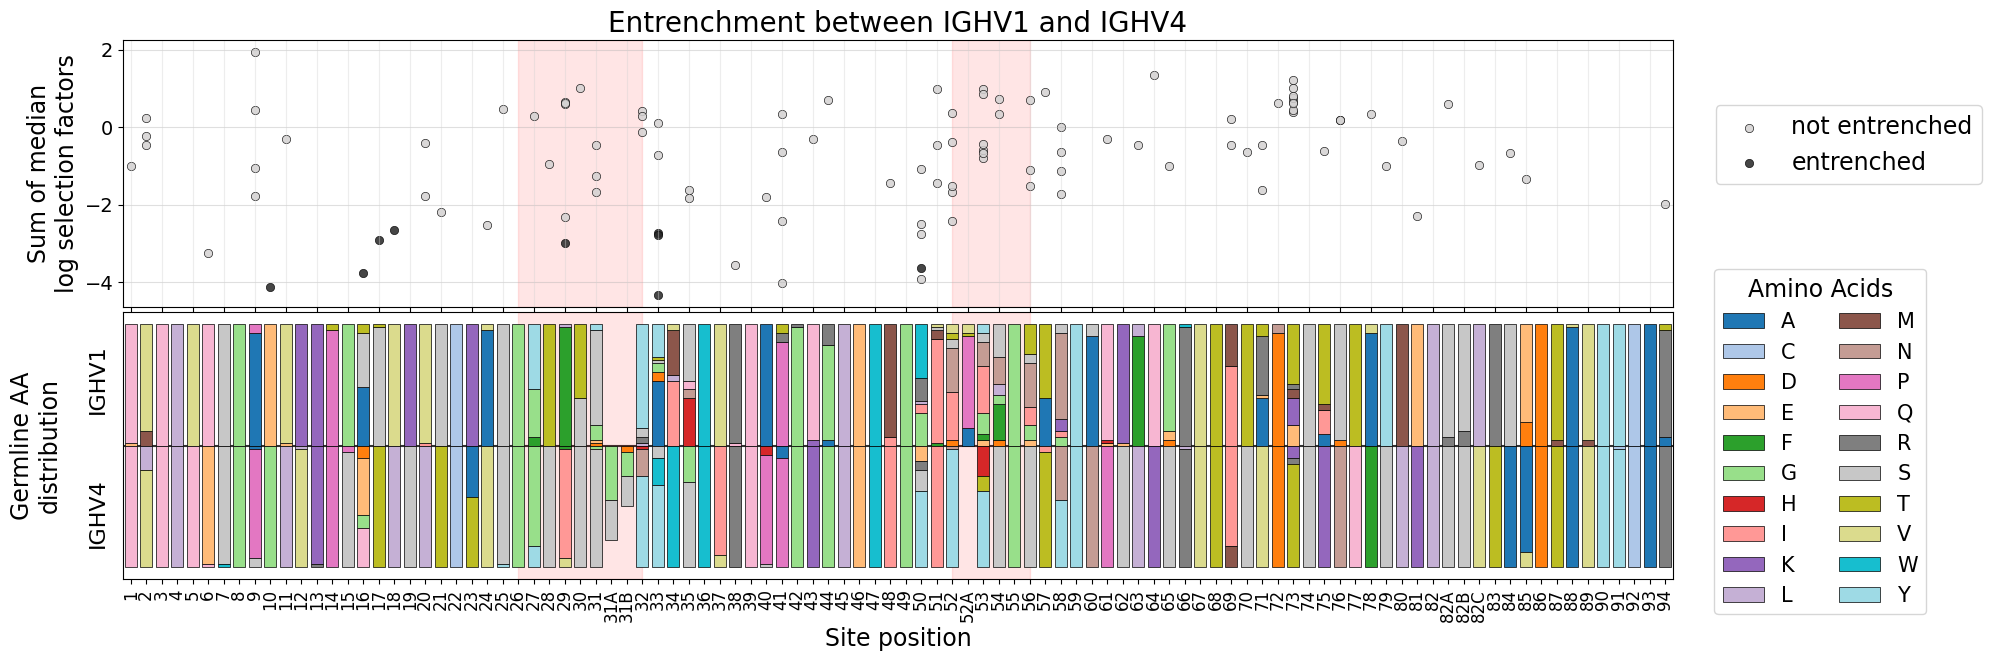

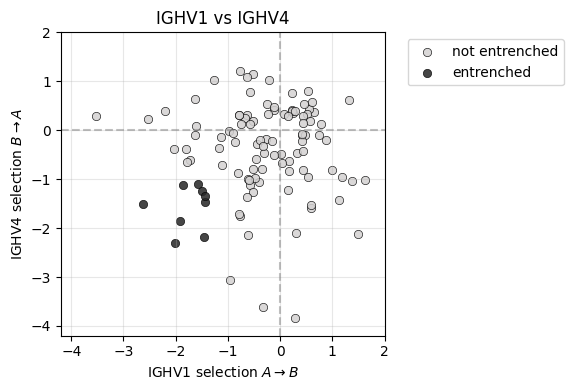

/tmp/ipykernel_120669/2572439647.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


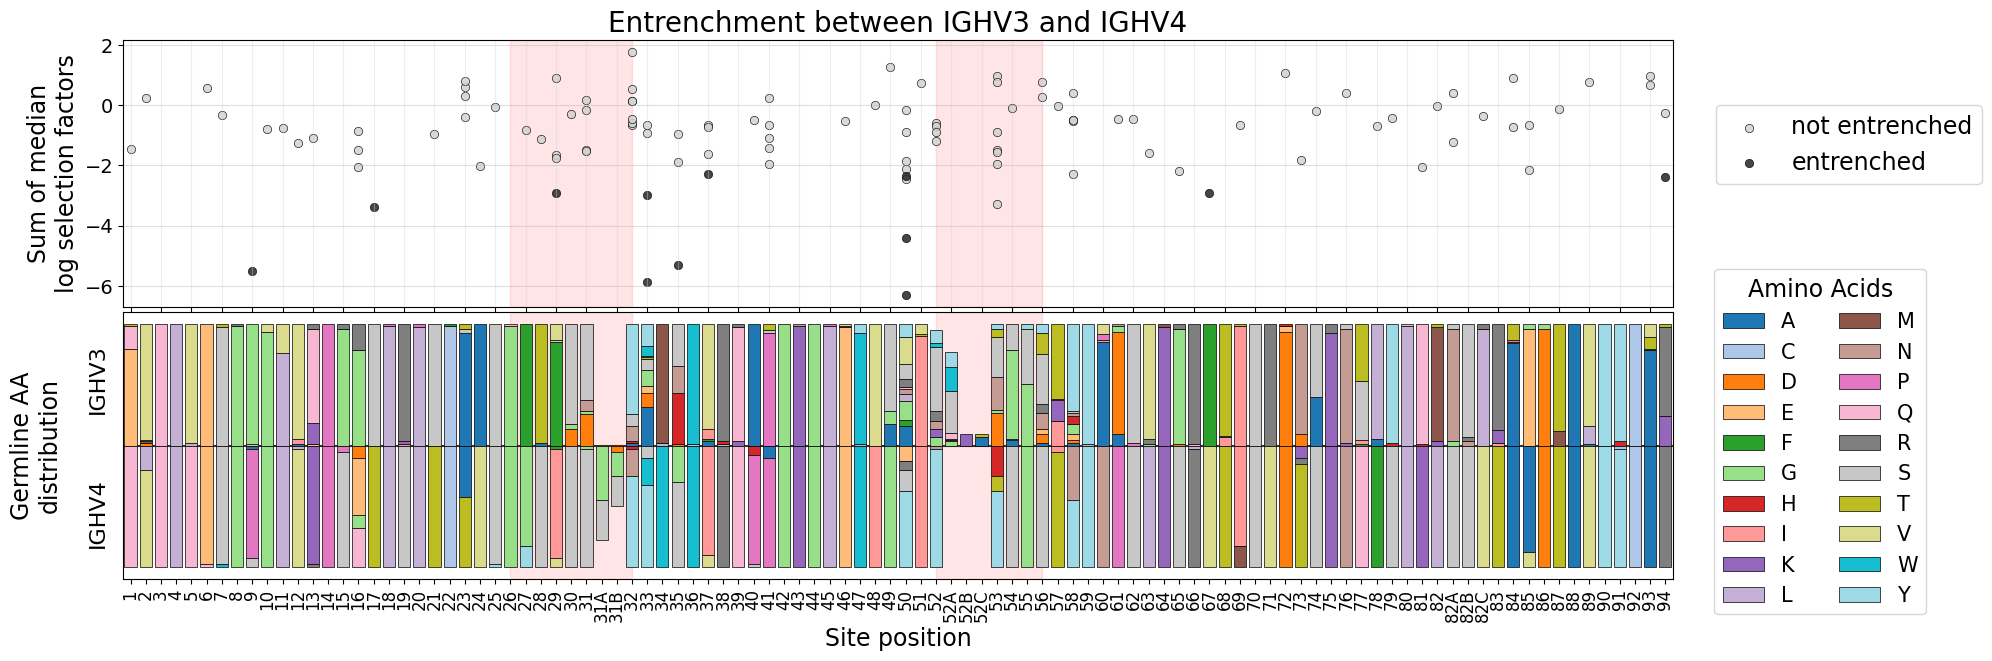

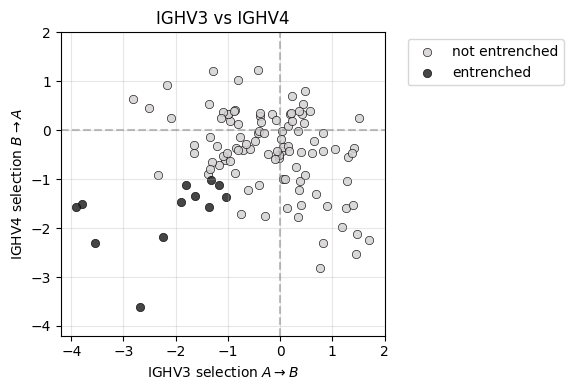

/tmp/ipykernel_120669/2572439647.py:364: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


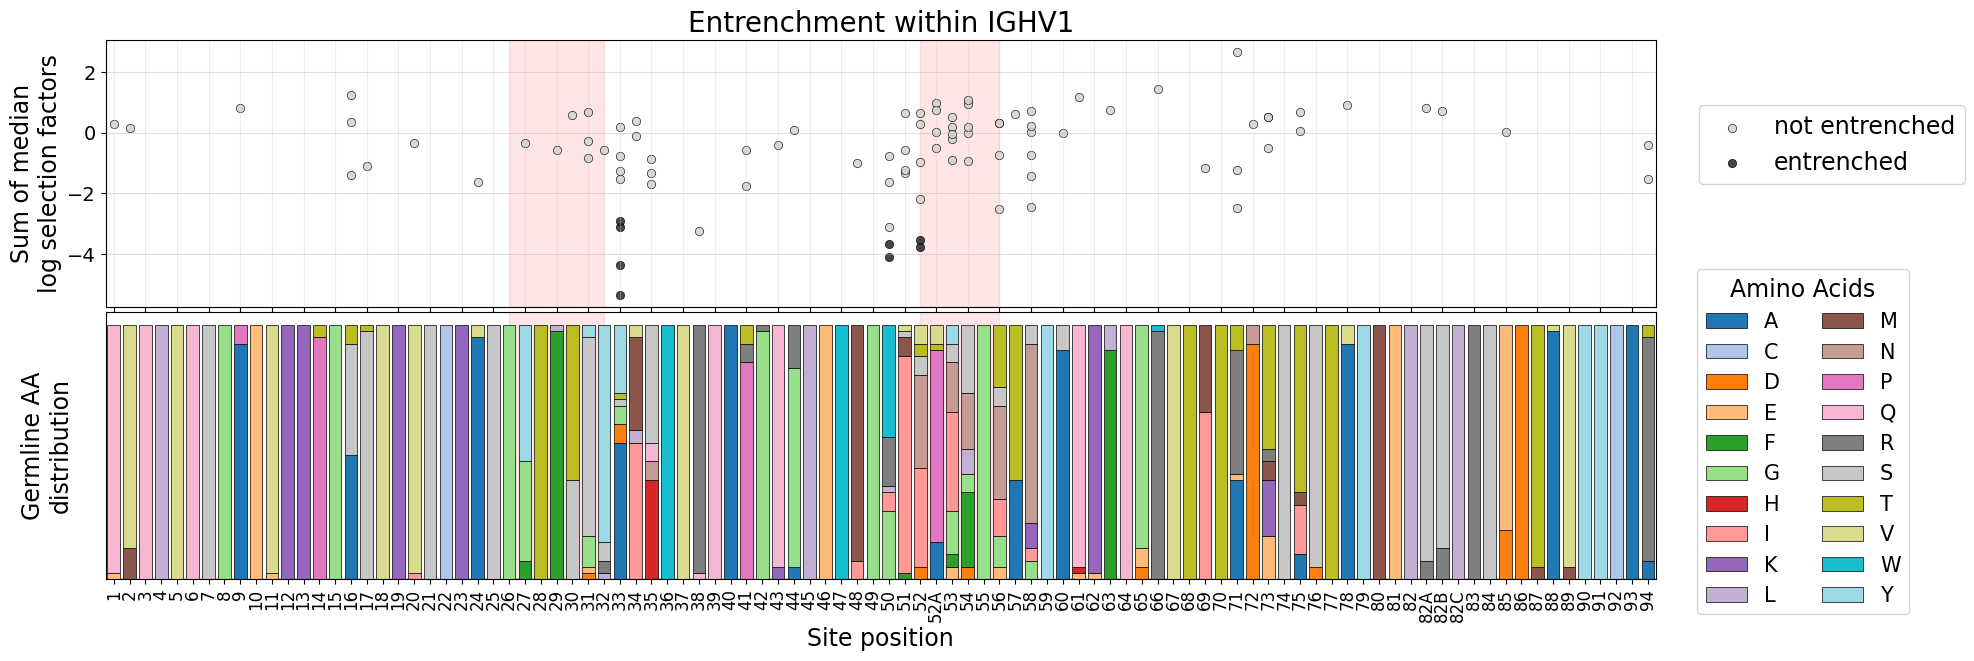

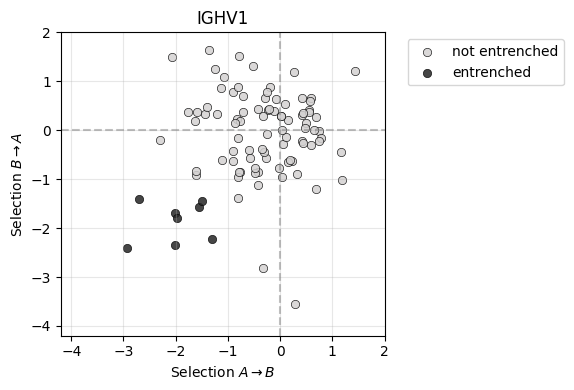

/tmp/ipykernel_120669/2572439647.py:364: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


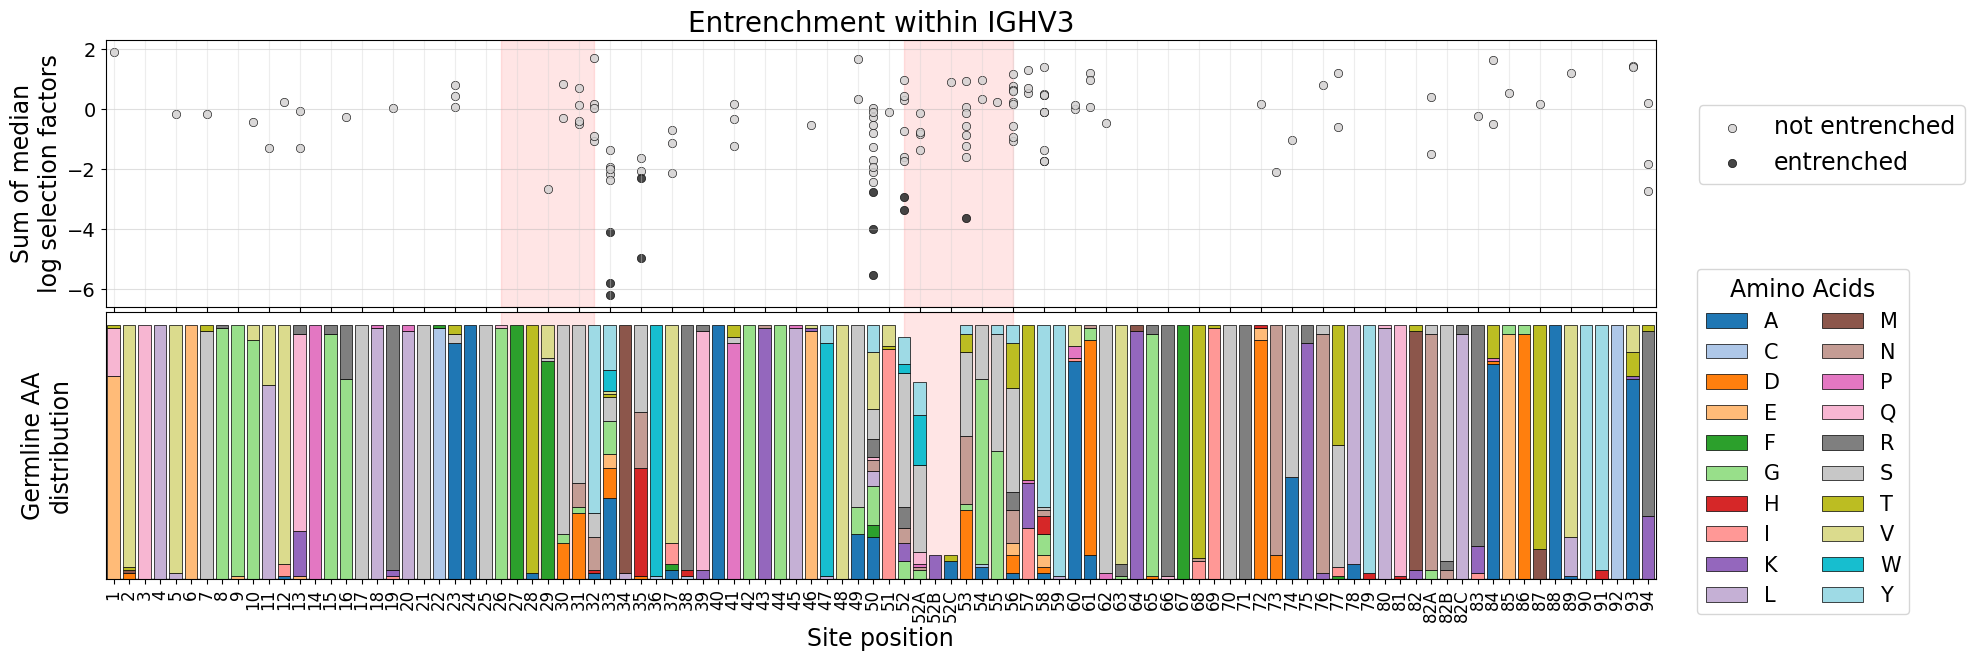

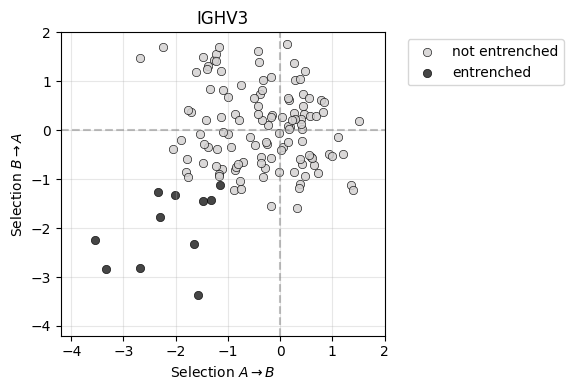

/tmp/ipykernel_120669/2572439647.py:364: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


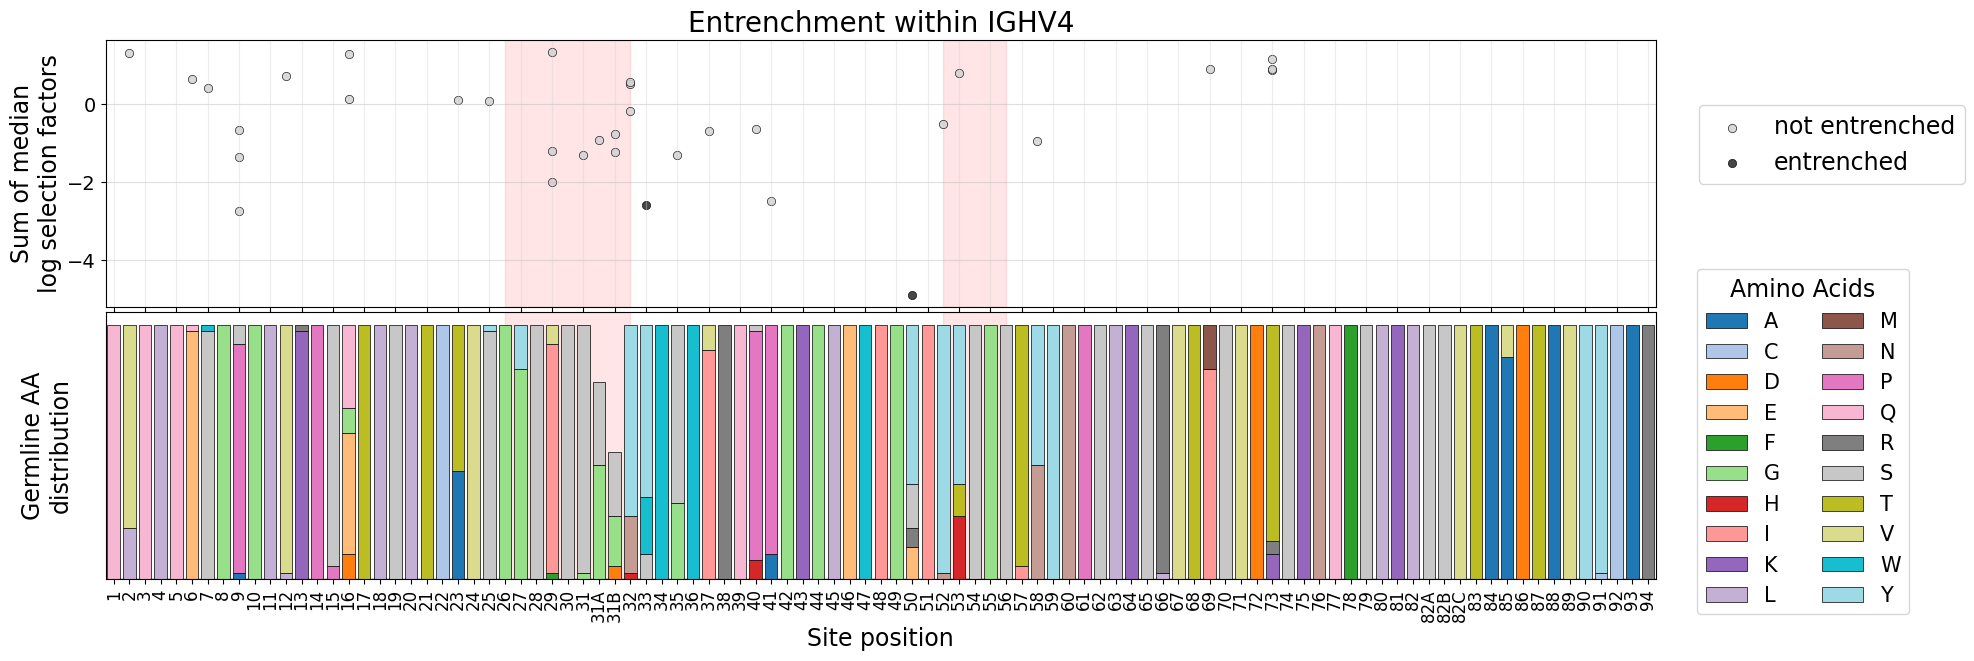

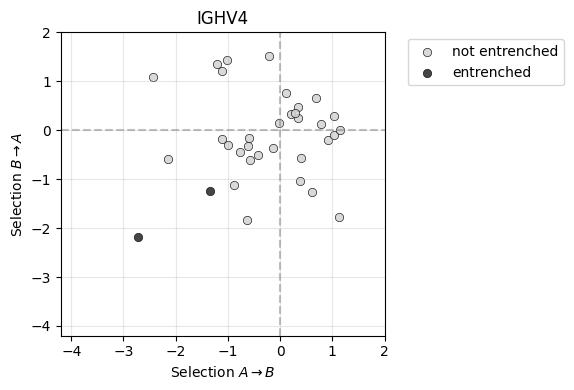

In [7]:
# pairwise comparison of all v families
v_families = ['IGHV1', 'IGHV3', 'IGHV4',]

# between v families
for v_family1 in v_families:
    for v_family2 in v_families:
        if v_family1 != v_family2 and v_family1 < v_family2:
            temp_df = compare_group_2_sites_between_vfamilies_with_distribution(
                aa_site_subs_selection_df_germline, germline_codons_df, v_family1, v_family2, 
                one_mutation_away=True, limit_pcp_depth=True, save_results=True, numbering_scheme=numbering_scheme,
                )
# within v families
for i in v_families:
    temp_df = compare_group_2_sites_within_vfamily_with_distribution(
        aa_site_subs_selection_df_germline, germline_codons_df, i, 
        one_mutation_away=True, limit_pcp_depth=True, save_results=True, numbering_scheme=numbering_scheme,
    )

In [8]:
## plot the between v families comparison, but mark which sites are also entrenched within v family

def compare_group_2_sites_between_vfamilies_with_within_overlay(
    germline_codons_df,
    v_family1, v_family2, 
    numbering_scheme='imgt',
    figsize=(20, 7), 
    save_fig=False,
    output_dir=None,
    debug=False):
    '''
    Create overlay plot showing between-family entrenchment with within-family entrenchment marked.
    
    This function reads pre-computed entrenchment results and creates a visualization showing
    which sites are entrenched at different hierarchical levels, with the same layout as
    compare_group_2_sites_between_vfamilies_with_distribution.
    
    Parameters:
    -----------
    germline_codons_df : DataFrame
        Germline codon data for amino acid distribution plot
    v_family1, v_family2 : str
        V family names to compare (e.g., 'IGHV1', 'IGHV3')
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    figsize : tuple
        Figure size
    save_fig : bool
        Whether to save the figure
    output_dir : str, optional
        Directory containing the entrenchment analysis results
        If None, defaults to f'_output/entrenchment_analysis/{numbering_scheme}/'
    debug : bool
        Print debug information
    
    Returns:
    --------
    compare_df : DataFrame
        Comparison dataframe with entrenchment categories
    fig : matplotlib.figure.Figure
        The figure object
    (ax1, ax2) : tuple
        The two axes objects
    '''
    import pandas as pd
    import matplotlib.pyplot as plt
    
    # Set default output directory
    if output_dir is None:
        output_dir = f'_output/entrenchment_analysis/{numbering_scheme}/'
    
    # Load the pre-computed comparison results
    comparison_file = f'{output_dir}comparison_{v_family1}_vs_{v_family2}.csv'
    compare_df = pd.read_csv(comparison_file, dtype={'site': str})
    
    if debug:
        print(f"Loaded comparison data from {comparison_file}")
        print(f"  Shape: {compare_df.shape}")
    
    # Load within-family entrenchment results
    within_entrenched_dict = {}
    for v_fam in [v_family1, v_family2]:
        within_file = f'{output_dir}entrenched_aa_sites_within_{v_fam}.csv'
        try:
            df = pd.read_csv(within_file, dtype={'site': str})
            within_entrenched_dict[v_fam] = set(
                zip(df['site'], df['amino_acid'], df['target_amino_acid'])
            )
            if debug:
                print(f"Loaded {len(within_entrenched_dict[v_fam])} entrenched pairs for {v_fam}")
                print(f"  Unique sites: {sorted(set([x[0] for x in within_entrenched_dict[v_fam]]))}")
        except FileNotFoundError:
            if debug:
                print(f"Warning: No within-family entrenchment file found for {v_fam}")
            within_entrenched_dict[v_fam] = set()
    
    # Add columns to mark if this site+aa pair is entrenched within each family
    def check_entrenched_in_family(row, v_fam):
        if v_fam not in within_entrenched_dict or len(within_entrenched_dict[v_fam]) == 0:
            return False
        entrenched_set = within_entrenched_dict[v_fam]
        match1 = (row['site'], row['parent_aa_1_and_target_aa_2'], row['parent_aa_2_and_target_aa_1']) in entrenched_set
        match2 = (row['site'], row['parent_aa_2_and_target_aa_1'], row['parent_aa_1_and_target_aa_2']) in entrenched_set
        return match1 or match2
    
    compare_df['entrenched_within_family1'] = compare_df.apply(lambda row: check_entrenched_in_family(row, v_family1), axis=1)
    compare_df['entrenched_within_family2'] = compare_df.apply(lambda row: check_entrenched_in_family(row, v_family2), axis=1)

    # Create category column for easier plotting (3 categories)
    def categorize_entrenchment(row):
        if not row['is_entrenched']:
            return 'not_entrenched'
        elif row['entrenched_within_family1'] or row['entrenched_within_family2']:
            return 'overlap_within'
        else:
            return 'new_addition'
    
    compare_df['entrenchment_category'] = compare_df.apply(categorize_entrenchment, axis=1)

    if debug:
        print(f"\nMatching results:")
        print(f"  Rows with is_entrenched=True: {compare_df['is_entrenched'].sum()}")
        print(f"  Rows matched to {v_family1} within: {compare_df['entrenched_within_family1'].sum()}")
        print(f"  Rows matched to {v_family2} within: {compare_df['entrenched_within_family2'].sum()}")
        
        print("\nCategory counts:")
        print(compare_df['entrenchment_category'].value_counts())

    # Get data for amino acid distribution
    family1_data = germline_codons_df[germline_codons_df.v_family == v_family1].copy()
    family2_data = germline_codons_df[germline_codons_df.v_family == v_family2].copy()
    
    # Get all sites and sort them properly
    all_sites_with_data = sorted(set(family1_data['site'].unique()) | set(family2_data['site'].unique()))
    sorted_sites = sort_antibody_sites(all_sites_with_data)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    # Check for data
    if len(sorted_sites) == 0:
        print("Warning: No data found for one or both V families")
        return compare_df, None, None
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # ===== TOP PLOT: SCATTER PLOT WITH CATEGORIZED COLORS =====
    # Add CDR shading first
    add_cdr_shading(ax1, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Define colors and markers for each category (3 categories)
    category_config = {
        'not_entrenched': {'color': '#D4D2D2', 'marker': 'o', 'label': 'not entrenched', 'alpha':0.85},
        'overlap_within': {'color': '#262626', 'marker': 'o', 'label': 'entrenched\n(overlap with within-family)', 'alpha':0.85},
        'new_addition': {'color': '#262626', 'marker': '*', 'label': 'entrenched\n(new addition)', 'alpha':1.0}
    }
    
    # Plot each category
    for category in ['not_entrenched', 'overlap_within', 'new_addition']:
        subset = compare_df[compare_df['entrenchment_category'] == category]
        if len(subset) > 0:
            subset_x = [site_to_position[site] for site in subset['site']]
            config = category_config[category]
            ax1.scatter(subset_x, subset['sum'], 
                       alpha=config['alpha'],
                       label=config['label'],
                       color=config['color'],
                       marker=config['marker'],
                       s=150 if category == 'new_addition' else 50,
                       edgecolors='black' if category != 'not_entrenched' else 'none',
                       linewidth=0.5)
            if debug:
                print(f"Plotting {len(subset)} points for {category} at sites: {sorted(subset['site'].unique())}")
    
    ax1.set_ylabel('Sum of median\nlog selection factors', fontsize=17)
    ax1.tick_params(axis='y', labelsize=14)
    #ax1.set_title(f'Selection factor sum comparison (with within-family entrenchment overlay)\n{v_family1} vs {v_family2}', fontsize=13)
    ax1.set_title(f'Entrenchment between {v_family1} and {v_family2}', fontsize=20)
    ax1.grid(True, axis='y', alpha=0.4, linewidth=0.8)
    for i in range(0, len(sorted_sites), 2):
        ax1.axvline(i, color='lightgray', alpha=0.4, linewidth=0.8)
    ax1.legend(bbox_to_anchor=(1.02, 0.8), loc='upper left', fontsize=17)
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION =====
    # Add CDR shading first
    add_cdr_shading(ax2, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Calculate percentages for family1 at specific sites
    family1_site_counts = {}
    for aa in AA_STR_SORTED:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family1_site_counts[aa] = site_counts
    
    # Calculate percentages for family2 at specific sites  
    family2_site_counts = {}
    for aa in AA_STR_SORTED:
        aa_data = family2_data[family2_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family2_site_counts[aa] = site_counts
    
    # Plot family1 above x-axis (positive values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom1 = 0
        site_total = family1_data['v_gene'].nunique()
        
        for aa in AA_STR_SORTED:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site_pos, percentage, bottom=bottom1, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Plot family2 below x-axis (negative values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom2 = 0
        site_total = family2_data['v_gene'].nunique()
        
        for aa in AA_STR_SORTED:
            count = family2_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = -(count / site_total) * 100  # Negative for below x-axis
                ax2.bar(site_pos, percentage, bottom=bottom2, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom2 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'Germline AA\ndistribution\n\n', fontsize=17)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1.5, zorder=0)
    # Add family labels to top and bottom halves
    ax2.text(-0.01, 0.75, v_family1, transform=ax2.transAxes, fontsize=16, ha='right', va='center', rotation=90)
    ax2.text(-0.01, 0.25, v_family2, transform=ax2.transAxes, fontsize=16, ha='right', va='center', rotation=90)

    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in AA_STR_SORTED:
        # Check if this amino acid appears in either family
        if any(family1_site_counts[aa].values) or any(family2_site_counts[aa].values):
            legend_handles.append(plt.Rectangle((0,0),1,1, fc=PALETTE_AA[aa], edgecolor='black', linewidth=0.))
            legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, 
              bbox_to_anchor=(1.02, 1.2), loc='upper left', 
              ncol=2, fontsize=15, title='Amino Acids', title_fontsize=17)
    
    # Set x-axis properties for both plots
    ax1.set_xticks(range(0, len(sorted_sites), 2))  # Grid at every other position
    ax1.set_xticklabels([])  # Remove x labels from top plot
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    
    ax2.set_xticks(range(len(sorted_sites)))
    ax2.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax2.set_xlabel(f'Site position - {numbering_scheme}', fontsize=17)
    ax2.set_xticklabels(sorted_sites, rotation=90, fontsize=12)
    ax2.set_yticks([])
    
    plt.tight_layout()
    plt.show()

    if save_fig:
        fig.savefig(f'{output_dir}{v_family1}_vs_{v_family2}_group2_with_within_overlay.pdf', dpi=300, bbox_inches='tight')
    
    return compare_df, fig, (ax1, ax2)

Loaded comparison data from _output/entrenchment_analysis/chothia/comparison_IGHV1_vs_IGHV3.csv
  Shape: (202, 9)
Loaded 16 entrenched pairs for IGHV1
  Unique sites: ['33', '50', '52']
Loaded 22 entrenched pairs for IGHV3
  Unique sites: ['33', '35', '50', '52', '53']

Matching results:
  Rows with is_entrenched=True: 17
  Rows matched to IGHV1 within: 8
  Rows matched to IGHV3 within: 12

Category counts:
entrenchment_category
not_entrenched    185
overlap_within     12
new_addition        5
Name: count, dtype: int64
Plotting 185 points for not_entrenched at sites: ['1', '11', '13', '17', '18', '19', '2', '20', '23', '24', '27', '29', '30', '31', '32', '33', '34', '35', '38', '41', '43', '44', '46', '48', '49', '5', '50', '51', '52', '52A', '53', '54', '55', '56', '57', '58', '6', '60', '61', '63', '64', '66', '67', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '80', '81', '82', '82A', '82B', '83', '84', '85', '87', '89', '93', '94']
Plotting 12 points for overlap_

/tmp/ipykernel_120669/4134451098.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


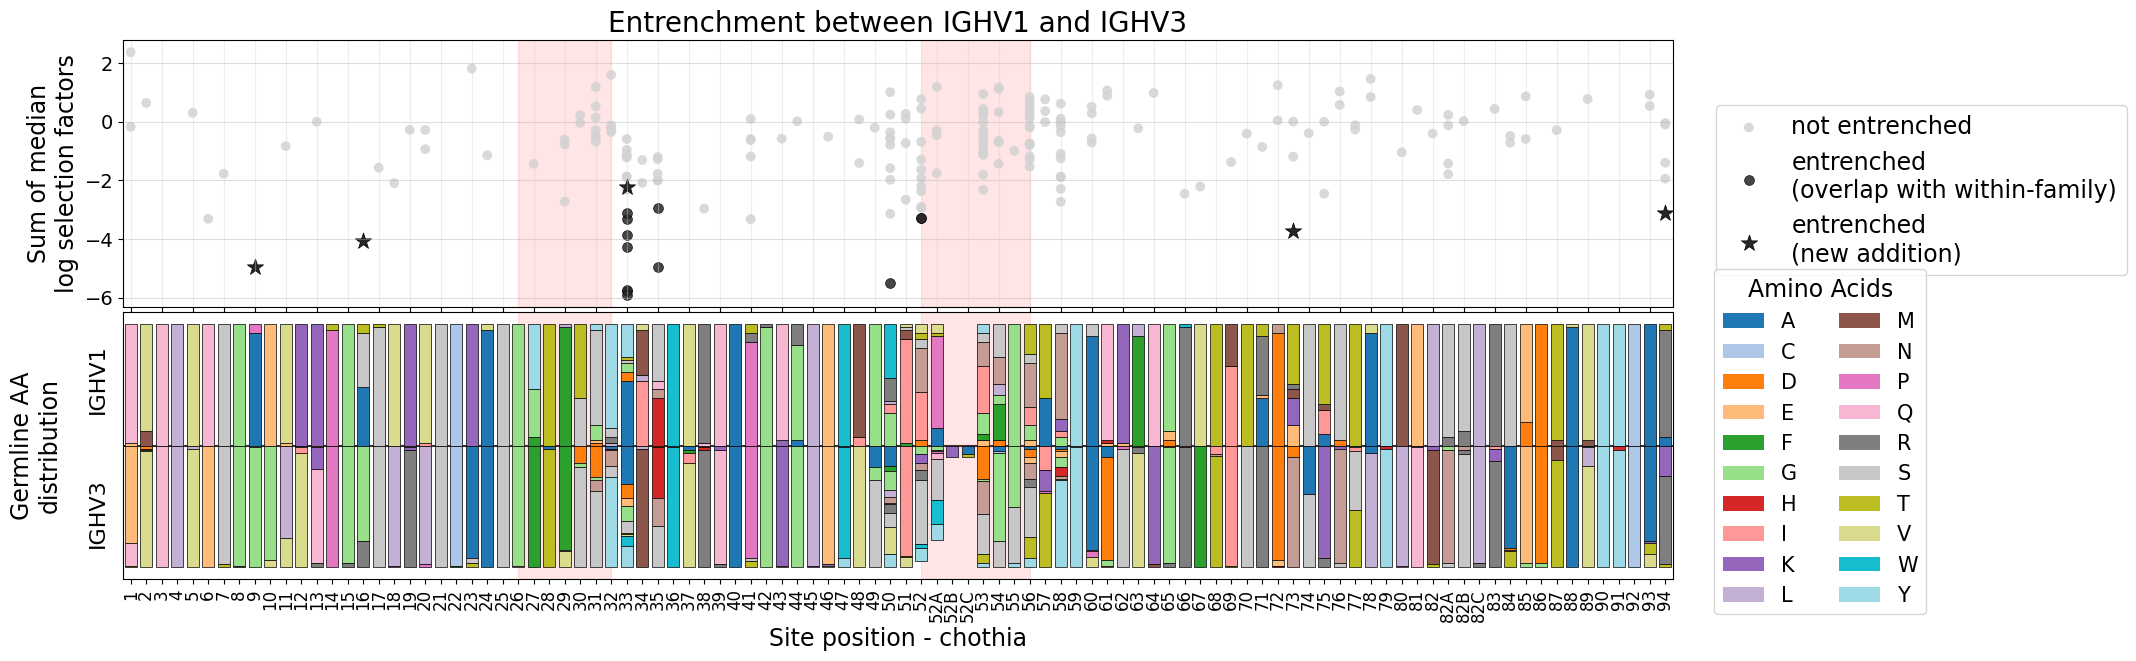

Loaded comparison data from _output/entrenchment_analysis/chothia/comparison_IGHV1_vs_IGHV4.csv
  Shape: (108, 9)
Loaded 16 entrenched pairs for IGHV1
  Unique sites: ['33', '50', '52']
Loaded 4 entrenched pairs for IGHV4
  Unique sites: ['33', '50']

Matching results:
  Rows with is_entrenched=True: 9
  Rows matched to IGHV1 within: 3
  Rows matched to IGHV4 within: 3

Category counts:
entrenchment_category
not_entrenched    99
new_addition       5
overlap_within     4
Name: count, dtype: int64
Plotting 99 points for not_entrenched at sites: ['1', '11', '2', '20', '21', '24', '25', '27', '28', '29', '30', '31', '32', '33', '35', '38', '40', '41', '43', '44', '48', '50', '51', '52', '53', '54', '56', '57', '58', '6', '61', '63', '64', '65', '69', '70', '71', '72', '73', '75', '76', '78', '79', '80', '81', '82A', '82C', '84', '85', '9', '94']
Plotting 4 points for overlap_within at sites: ['33', '50']
Plotting 5 points for new_addition at sites: ['10', '16', '17', '18', '29']


/tmp/ipykernel_120669/4134451098.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


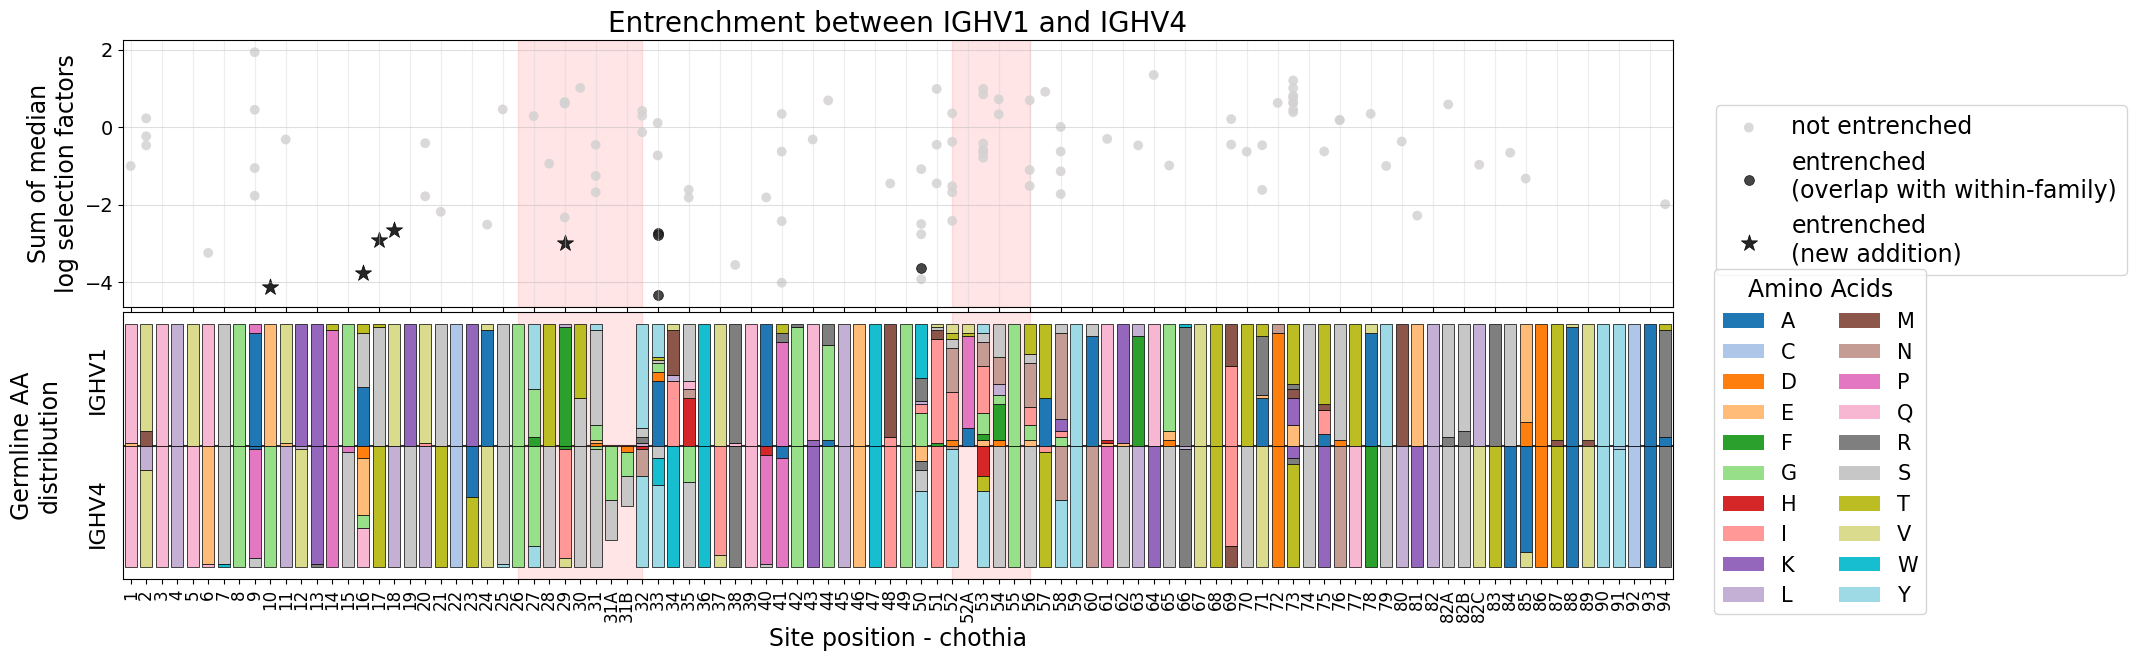

Loaded comparison data from _output/entrenchment_analysis/chothia/comparison_IGHV3_vs_IGHV4.csv
  Shape: (114, 9)
Loaded 22 entrenched pairs for IGHV3
  Unique sites: ['33', '35', '50', '52', '53']
Loaded 4 entrenched pairs for IGHV4
  Unique sites: ['33', '50']

Matching results:
  Rows with is_entrenched=True: 12
  Rows matched to IGHV3 within: 5
  Rows matched to IGHV4 within: 2

Category counts:
entrenchment_category
not_entrenched    102
new_addition        7
overlap_within      5
Name: count, dtype: int64
Plotting 102 points for not_entrenched at sites: ['1', '10', '11', '12', '13', '16', '2', '21', '23', '24', '25', '27', '28', '29', '30', '31', '32', '33', '35', '37', '40', '41', '46', '48', '49', '50', '51', '52', '53', '54', '56', '57', '58', '6', '61', '62', '63', '65', '69', '7', '72', '73', '74', '76', '78', '79', '81', '82', '82A', '82C', '84', '85', '87', '89', '93', '94']
Plotting 5 points for overlap_within at sites: ['33', '50']
Plotting 7 points for new_addition at s

/tmp/ipykernel_120669/4134451098.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


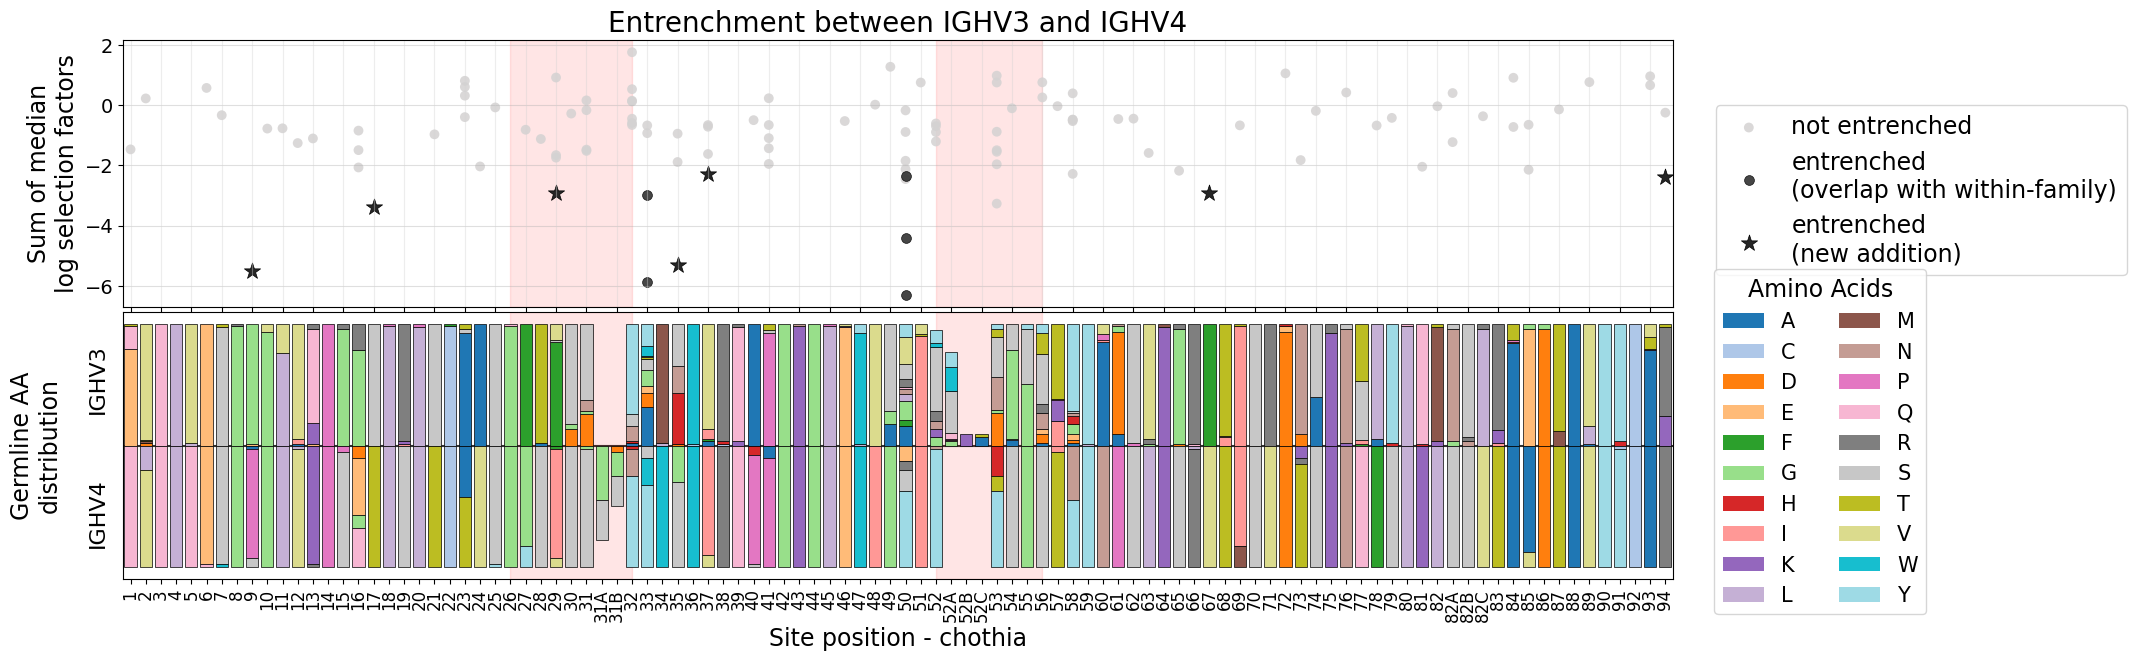

In [9]:
# After running the comparison functions that save the data
compare_df, fig, (ax1, ax2) = compare_group_2_sites_between_vfamilies_with_within_overlay(
    germline_codons_df,
    'IGHV1', 
    'IGHV3',
    numbering_scheme=numbering_scheme,
    save_fig=True,
    debug=True
)

compare_df, fig, (ax1, ax2) = compare_group_2_sites_between_vfamilies_with_within_overlay(
    germline_codons_df,  
    'IGHV1', 
    'IGHV4',
    numbering_scheme=numbering_scheme,
    save_fig=True,
    debug=True
)

compare_df, fig, (ax1, ax2) = compare_group_2_sites_between_vfamilies_with_within_overlay(
    germline_codons_df, 
    'IGHV3', 
    'IGHV4',
    numbering_scheme=numbering_scheme,
    save_fig=True,
    debug=True
)

/tmp/ipykernel_120669/2572439647.py:364: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


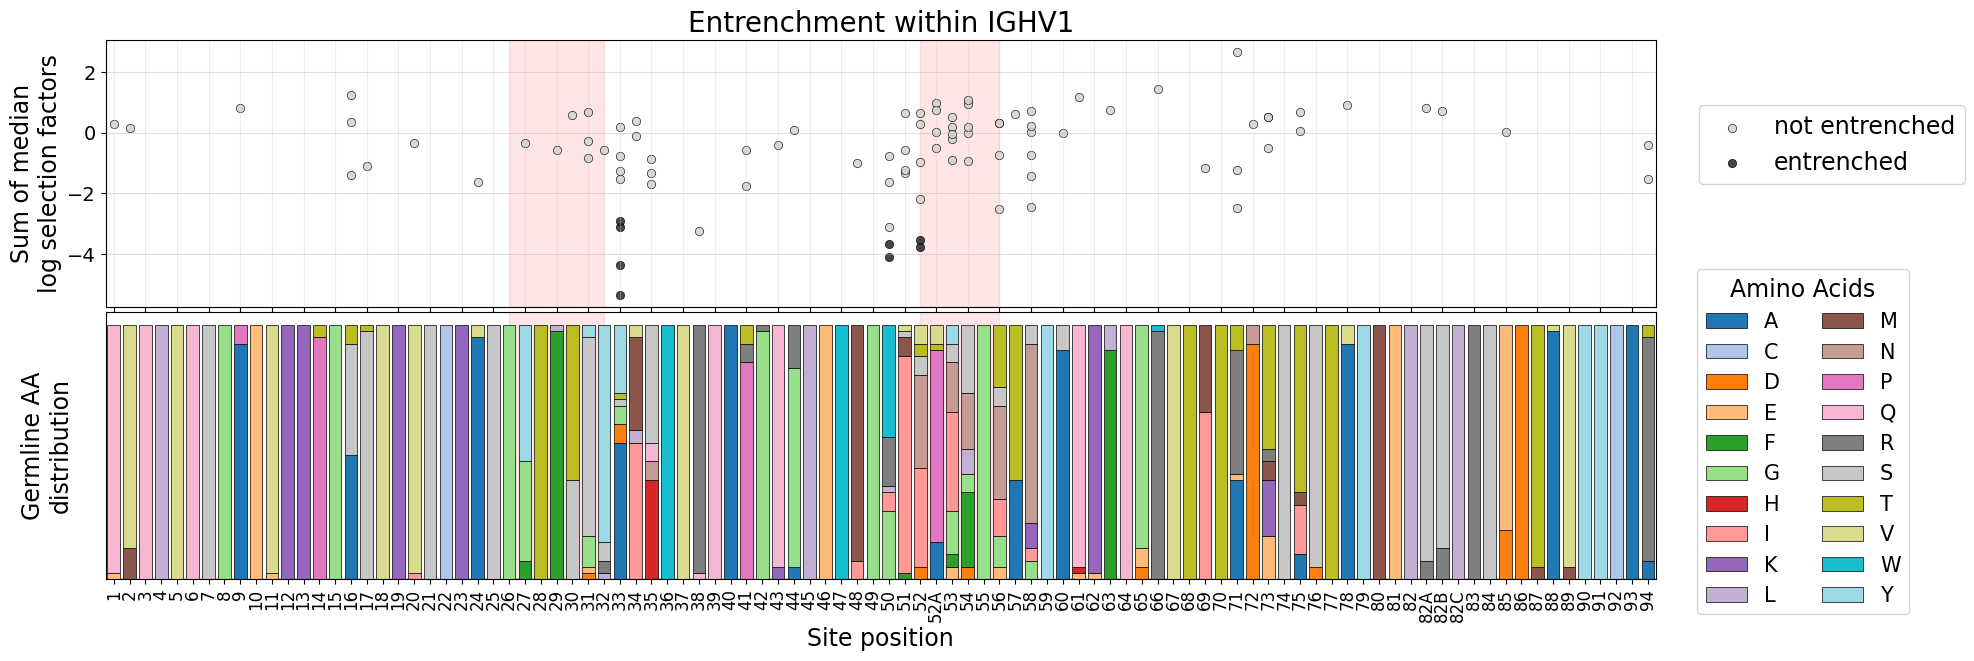

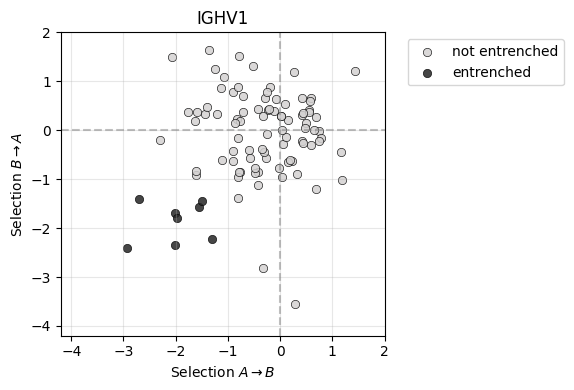

/tmp/ipykernel_120669/2572439647.py:364: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


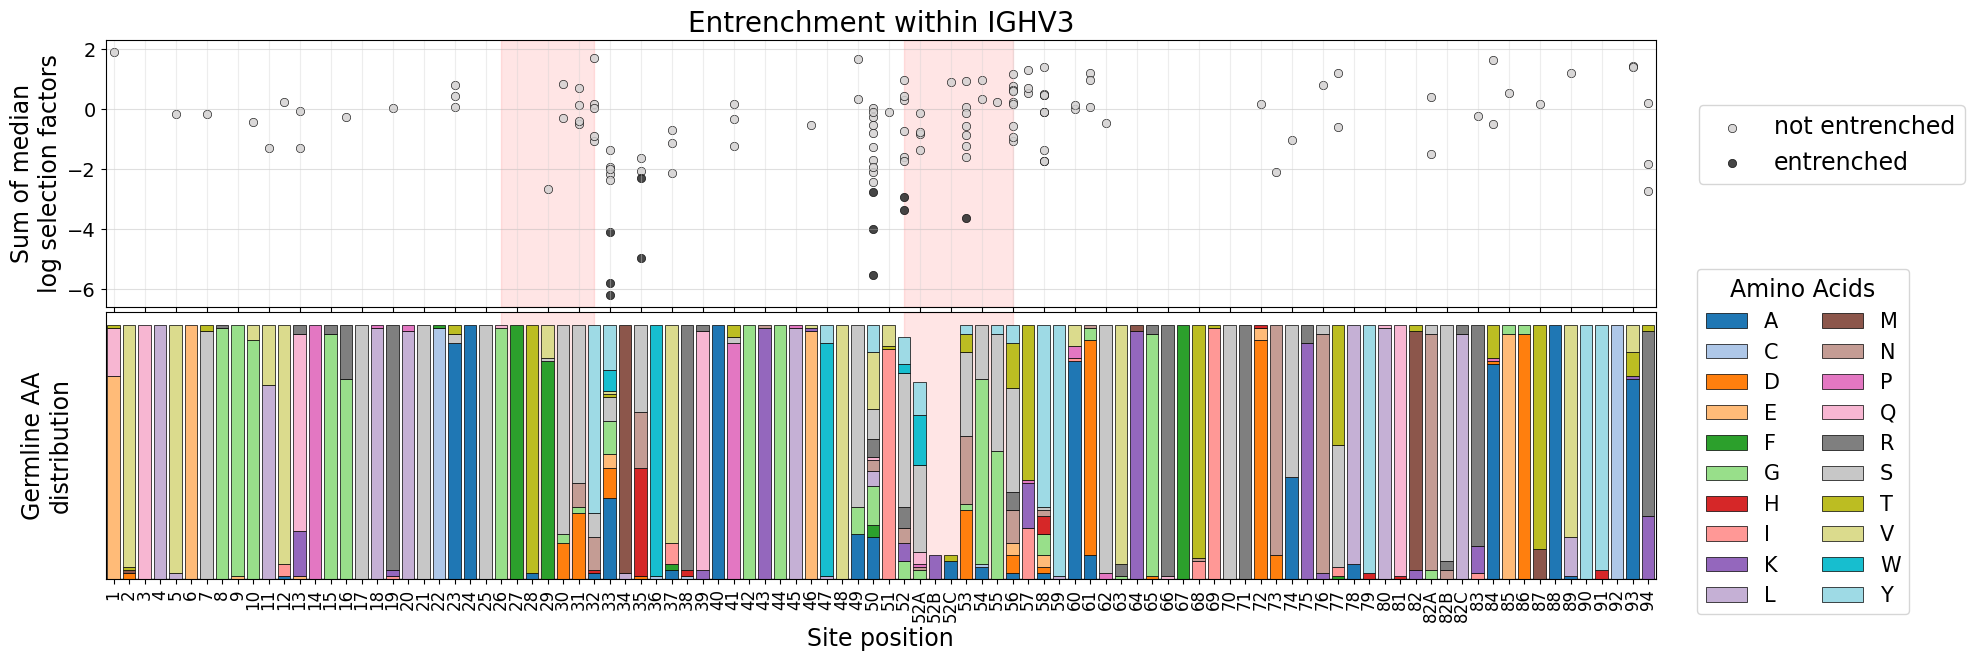

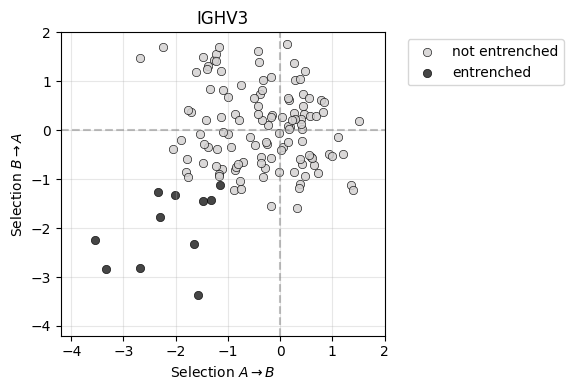

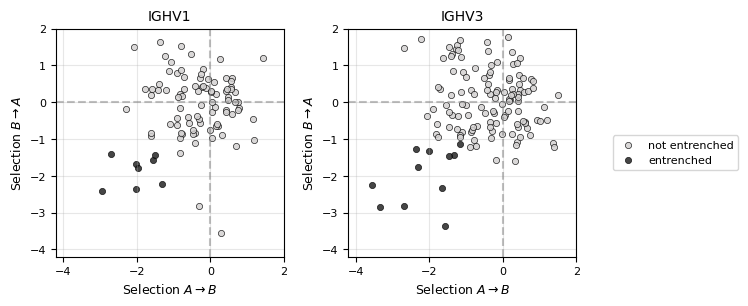

In [10]:
# create side by side reciprocal selection plots for ighv1 and ighv3 within v family comparisons for the paper

df_ighv1 = compare_group_2_sites_within_vfamily_with_distribution(
    aa_site_subs_selection_df_germline, germline_codons_df, 'IGHV1',
    one_mutation_away=True, limit_pcp_depth=True, numbering_scheme=numbering_scheme, save_results=False)

df_ighv3 = compare_group_2_sites_within_vfamily_with_distribution(
    aa_site_subs_selection_df_germline, germline_codons_df, 'IGHV3',
    one_mutation_away=True, limit_pcp_depth=True, numbering_scheme=numbering_scheme, save_results=False)

def plot_reciprocal_selection_factors_within_vfamily_side_by_side(
    compare_df_1, compare_df_2, v_family1, v_family2, save_results=False
):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))
    
    for ax, compare_df, v_family in [(ax1, compare_df_1, v_family1), (ax2, compare_df_2, v_family2)]:
        for is_sig in [False, True]:  # fixed order so legend is consistent
            subset = compare_df[compare_df['is_entrenched'] == is_sig]
            subset = subset[subset.parent_aa_1_and_target_aa_2 < subset.parent_aa_2_and_target_aa_1]
            color = '#262626' if is_sig else '#D4D2D2'
            label = 'entrenched' if is_sig else 'not entrenched'
            ax.scatter(subset['log_selection_factor_1'], 
                       subset['log_selection_factor_2'],
                       alpha=0.85, label=label, color=color, edgecolor='black', linewidth=0.5, s=20)
        
        ax.set_xlabel(r'Selection $A \to B$', fontsize=9)
        ax.set_ylabel(r'Selection $B \to A$', fontsize=9)
        ax.tick_params(axis='both', labelsize=8)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(v_family, fontsize=10)
        ax.set_xlim(-4.2, 2)
        ax.set_ylim(-4.2, 2)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    
    # Single shared legend from first axes (both have same labels)
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc='center left', fontsize=8)
    
    plt.tight_layout()
    if save_results:
        fig.savefig(f'{output_dir}/within_{v_family1}_and_{v_family2}_reciprocal_selection.pdf', 
                    dpi=300, bbox_inches='tight')
    plt.show()

plot_reciprocal_selection_factors_within_vfamily_side_by_side(df_ighv1, df_ighv3, 'IGHV1', 'IGHV3', save_results=True)
